# 📘 Ejercicios de CPM y PERT en Python
Este notebook contiene una serie de ejercicios resueltos para aplicar los métodos **CPM (Critical Path Method)** y **PERT (Program Evaluation and Review Technique)**.

Incluye:
1. CPM básico
2. PERT con tiempos esperados
3. Varianza y desviación estándar (PERT avanzado)
4. Probabilidad de terminar en una fecha límite
5. Proyecto aleatorio con grafo


## Ejercicio 1 – CPM básico con actividades
Dado el proyecto con actividades y duraciones, calcular el **camino crítico** y la duración total.


In [1]:
import networkx as nx

# Definimos actividades con duraciones
activities = {
    "A": 3,
    "B": 2,
    "C": 4,
    "D": 2,
    "E": 3
}

dependencies = {
    "A": [],
    "B": ["A"],
    "C": ["A"],
    "D": ["B", "C"],
    "E": ["D"]
}

G = nx.DiGraph()
for task, preds in dependencies.items():
    for p in preds:
        G.add_edge(p, task, weight=activities[task])

critical_path = nx.dag_longest_path(G, weight="weight")
critical_path_length = nx.dag_longest_path_length(G, weight="weight")

print("Camino crítico:", critical_path)
print("Duración total del proyecto:", critical_path_length, "días")

Camino crítico: ['A', 'C', 'D', 'E']
Duración total del proyecto: 9 días


## Ejercicio 2 – PERT con tiempos esperados
Calcular el tiempo esperado de cada actividad y el camino crítico.


In [2]:
# Datos de actividades con tiempos (To, Tm, Tp)
activities = {
    "A": (2, 3, 4),
    "B": (1, 2, 3),
    "C": (3, 4, 7),
    "D": (1, 2, 3),
    "E": (2, 3, 4)
}

expected_times = {a: (t[0] + 4*t[1] + t[2]) / 6 for a, t in activities.items()}

dependencies = {
    "A": [],
    "B": ["A"],
    "C": ["A"],
    "D": ["B", "C"],
    "E": ["D"]
}

G = nx.DiGraph()
for task, preds in dependencies.items():
    for p in preds:
        G.add_edge(p, task, weight=expected_times[task])

critical_path = nx.dag_longest_path(G, weight="weight")
critical_path_length = nx.dag_longest_path_length(G, weight="weight")

print("Tiempos esperados:", expected_times)
print("Camino crítico:", critical_path)
print("Duración total esperada:", critical_path_length, "días")

Tiempos esperados: {'A': 3.0, 'B': 2.0, 'C': 4.333333333333333, 'D': 2.0, 'E': 3.0}
Camino crítico: ['A', 'C', 'D', 'E']
Duración total esperada: 9.333333333333332 días


## Ejercicio 3 – Variabilidad del proyecto (PERT avanzado)
Calcular la varianza y desviación estándar del proyecto.


In [3]:
variances = {a: ((t[2] - t[0]) / 6) ** 2 for a, t in activities.items()}

project_variance = sum(variances[a] for a in critical_path)
project_std_dev = project_variance ** 0.5

print("Varianzas:", variances)
print("Varianza total del proyecto:", project_variance)
print("Desviación estándar:", project_std_dev)

Varianzas: {'A': 0.1111111111111111, 'B': 0.1111111111111111, 'C': 0.4444444444444444, 'D': 0.1111111111111111, 'E': 0.1111111111111111}
Varianza total del proyecto: 0.7777777777777777
Desviación estándar: 0.8819171036881968


## Ejercicio 4 – Probabilidad de terminar en una fecha límite
Usar distribución normal para calcular la probabilidad de cumplir un deadline.


In [4]:
import scipy.stats as st

deadline = 12
Z = (deadline - critical_path_length) / project_std_dev
prob = st.norm.cdf(Z)

print(f"Probabilidad de terminar en {deadline} días o menos: {prob:.2%}")

Probabilidad de terminar en 12 días o menos: 99.88%


## Ejercicio 5 – Proyecto aleatorio con grafo
Generar actividades aleatorias, calcular el camino crítico y dibujar el grafo.


Actividades: {'A': 1, 'B': 5, 'C': 3, 'D': 5, 'E': 1, 'F': 5}
Dependencias: {'A': [], 'B': ['A'], 'C': ['B'], 'D': ['A'], 'E': ['C'], 'F': ['B']}
Camino crítico: ['A', 'B', 'F']
Duración total: 10


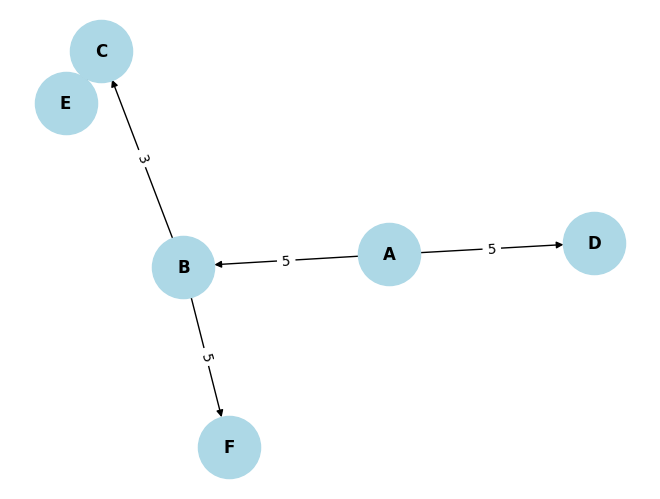

In [5]:
import random
import matplotlib.pyplot as plt

# Generar actividades aleatorias
n = 6
activities = {chr(65+i): random.randint(1, 5) for i in range(n)}

# Dependencias simples: cada actividad (excepto la primera) depende de alguna anterior
dependencies = {}
for i, act in enumerate(activities.keys()):
    if i == 0:
        dependencies[act] = []
    else:
        dependencies[act] = [random.choice(list(activities.keys())[:i])]

# Crear grafo
G = nx.DiGraph()
for task, preds in dependencies.items():
    for p in preds:
        G.add_edge(p, task, weight=activities[task])

# Calcular camino crítico
critical_path = nx.dag_longest_path(G, weight="weight")
critical_path_length = nx.dag_longest_path_length(G, weight="weight")

print("Actividades:", activities)
print("Dependencias:", dependencies)
print("Camino crítico:", critical_path)
print("Duración total:", critical_path_length)

# Dibujar grafo
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=12, font_weight='bold')
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
plt.show()